# Statistical validation

## tl;dr
The expanded validation covers lead-origin conversion, review-score robustness, and eligible M3 retention by acquisition origin.


## Context & Methods

Use chi-square with Cramér's V for categorical association, Wilson intervals for rates, Mann–Whitney plus bootstrap for review-score differences, and a separate M3 retention test using only eligible cohort observations. No result is interpreted as causal.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd().parent
stats = pd.read_csv(root / 'reports/qa/statistical_validation.csv')
retention = pd.read_csv(root / 'reports/tables/retention_by_origin.csv')
stats.head()


,test,method,statistic,p_value,sample_size,effect_size,metric,ci_low,ci_high,interpretation,n_on_time,n_late,mean_on_time,mean_late,median_on_time,median_late
0,lead_origin_vs_conversion,chi_square,137.687083,3.096154e-25,8000,0.131190,conversion_rate,NaN,NaN,association detected; Cramers V reported; not ...,NaN,NaN,NaN,NaN,NaN,NaN
1,conversion_ci:direct_traffic,wilson_95pct,NaN,NaN,499,0.112224,conversion_rate,0.087440,0.142934,descriptive interval,NaN,NaN,NaN,NaN,NaN,NaN
2,conversion_ci:display,wilson_95pct,NaN,NaN,118,0.050847,conversion_rate,0.023510,0.106507,descriptive interval,NaN,NaN,NaN,NaN,NaN,NaN
3,conversion_ci:email,wilson_95pct,NaN,NaN,493,0.030426,conversion_rate,0.018524,0.049589,descriptive interval,NaN,NaN,NaN,NaN,NaN,NaN
4,conversion_ci:organic_search,wilson_95pct,NaN,NaN,2296,0.118031,conversion_rate,0.105468,0.131871,descriptive interval,NaN,NaN,NaN,NaN,NaN,NaN


## Results

### Lead conversion intervals


,origin,sample_size,effect_size,ci_low,ci_high
1,direct_traffic,499,0.112224,0.087440,0.142934
2,display,118,0.050847,0.023510,0.106507
3,email,493,0.030426,0.018524,0.049589
4,organic_search,2296,0.118031,0.105468,0.131871
5,other,150,0.026667,0.010418,0.066554
6,other_publicities,65,0.046154,0.015820,0.127138
7,paid_search,1586,0.122951,0.107694,0.140029
8,referral,284,0.084507,0.057445,0.122660
9,social,1350,0.055556,0.044550,0.069083
10,unknown,1159,0.166523,0.146183,0.189066


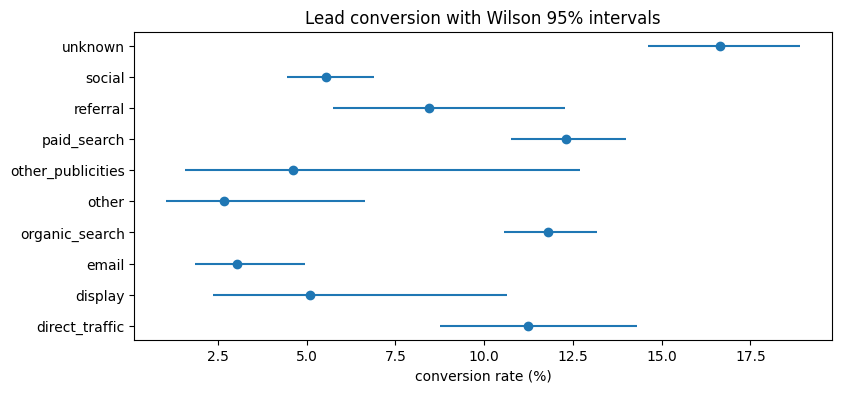

In [2]:
conversion = stats[stats['test'].str.startswith('conversion_ci:')].copy()
conversion['origin'] = conversion['test'].str.replace('conversion_ci:', '', regex=False)
display(conversion[['origin','sample_size','effect_size','ci_low','ci_high']])
fig, ax = plt.subplots(figsize=(9,4))
y = range(len(conversion))
ax.errorbar(conversion['effect_size']*100, list(y), xerr=[(conversion['effect_size']-conversion['ci_low'])*100, (conversion['ci_high']-conversion['effect_size'])*100], fmt='o')
ax.set_yticks(list(y)); ax.set_yticklabels(conversion['origin']); ax.set_xlabel('conversion rate (%)'); ax.set_title('Lead conversion with Wilson 95% intervals'); plt.show()


### Review-score robustness and M3 retention


,test,method,statistic,p_value,sample_size,effect_size,metric,ci_low,ci_high,interpretation,n_on_time,n_late,mean_on_time,mean_late,median_on_time,median_late
11,late_delivery_vs_review_score,mann_whitney_plus_bootstrap_mean_difference,1.524315e+08,0.000000,96361,-1.727243,mean_review_score_late_minus_ontime,-1.785215,-1.67379,late orders have different review scores; asso...,88661.0,7700.0,4.293737,2.566494,5.0,2.0
12,retention_m3_by_origin,chi_square,1.868440e+00,0.600156,281,0.081543,m3_retention_rate,NaN,NaN,channel differences are associative; only elig...,NaN,NaN,NaN,NaN,NaN,NaN


,origin,sample_size,effect_size,ci_low,ci_high
13,organic_search,88,0.431818,0.333327,0.536013
14,other_sparse,60,0.400000,0.285695,0.526339
15,paid_search,73,0.465753,0.355920,0.579011
16,unknown,60,0.516667,0.393078,0.638250


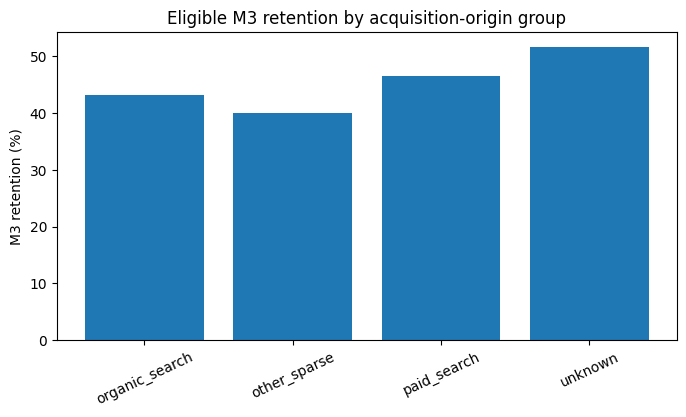

In [3]:
display(stats[stats['test'].isin(['late_delivery_vs_review_score','retention_m3_by_origin'])])
m3 = stats[stats['test'].str.startswith('retention_m3_ci:')].copy()
m3['origin'] = m3['test'].str.replace('retention_m3_ci:', '', regex=False)
display(m3[['origin','sample_size','effect_size','ci_low','ci_high']])
fig, ax = plt.subplots(figsize=(8,4)); ax.bar(m3['origin'], m3['effect_size']*100); ax.set_ylabel('M3 retention (%)'); ax.tick_params(axis='x', rotation=25); ax.set_title('Eligible M3 retention by acquisition-origin group'); plt.show()


## Takeaways

The tests prioritize diagnostics and experiment design. CIs, effect sizes, sample sizes and eligibility are retained beside p-values; the evidence remains associative.
